In [ ]:
#   Load the subsetted 

import pandas as pd
df = pd.read_parquet("../data/subsets/brfss2024_subset.parquet")
df.head()

,state_fips,primary_sampling_unit,sex_raw,general_health,days_poor_physical_health,days_poor_mental_health,days_poor_health_overall,insurance_type,has_personal_doctor,cant_afford_doctor,...,height_inches,weight_kg,bmi_x100,bmi_category,education_level,income_level,smoking_status,any_alcohol_past_30d,is_binge_drinker,is_heavy_drinker
0,1.0,2.024000e+09,2.0,3.0,2.0,88.0,88.0,3.0,2.0,2.0,...,64.0,5942.0,2249.0,2.0,2.0,9.0,4.0,2.0,1.0,1.0
1,1.0,2.024000e+09,1.0,1.0,88.0,88.0,NaN,3.0,1.0,2.0,...,70.0,8165.0,2583.0,3.0,4.0,7.0,3.0,2.0,1.0,1.0
2,1.0,2.024000e+09,1.0,2.0,30.0,88.0,1.0,1.0,3.0,1.0,...,78.0,8845.0,2253.0,2.0,3.0,9.0,1.0,1.0,2.0,1.0
3,1.0,2.024000e+09,1.0,1.0,88.0,88.0,NaN,3.0,1.0,2.0,...,68.0,7484.0,2509.0,3.0,4.0,4.0,4.0,2.0,1.0,1.0
4,1.0,2.024000e+09,1.0,3.0,88.0,88.0,NaN,5.0,1.0,2.0,...,68.0,5897.0,1977.0,2.0,3.0,2.0,4.0,2.0,1.0,1.0


Overall insurance coverage:
has_insurance
1.0    90.4
2.0     5.6
9.0     4.1
Name: proportion, dtype: float64


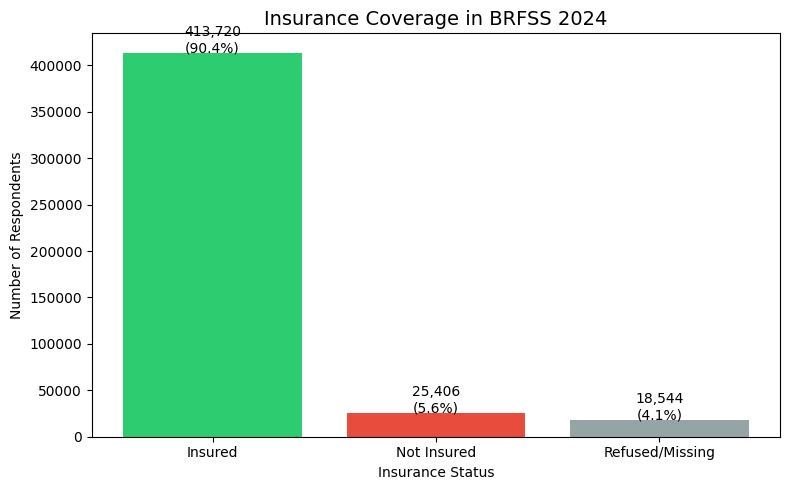

In [ ]:
# ── SECTION 1: Basic Insurance Coverage ─────────────────────────────

# Overall insurance rate
insurance_rate = df['has_insurance'].value_counts(normalize=True) * 100
print("Overall insurance coverage:")
print(insurance_rate.round(1))

# Make it into visual representation

import matplotlib.pyplot as plt

# Map numbers to labels
insurance_labels = {
    1.0: "Insured",
    2.0: "Not Insured",
    7.0: "Don't Know",
    9.0: "Refused/Missing"
}

insurance_data = df['has_insurance'].map(insurance_labels).value_counts()
percentages = df['has_insurance'].map(insurance_labels).value_counts(normalize=True) * 100

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(insurance_data.index, insurance_data.values, color=['#2ecc71', '#e74c3c', '#95a5a6', '#bdc3c7'])

# Add count + percentage labels on bars
for bar, pct in zip(bars, percentages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{bar.get_height():,.0f}\n({pct:.1f}%)',
            ha='center', fontsize=10)

ax.set_title('Do you have any health insurance?', fontsize=14)
ax.set_ylabel('Number of Respondents')
ax.set_xlabel('Insurance Status')
plt.tight_layout()
plt.show()

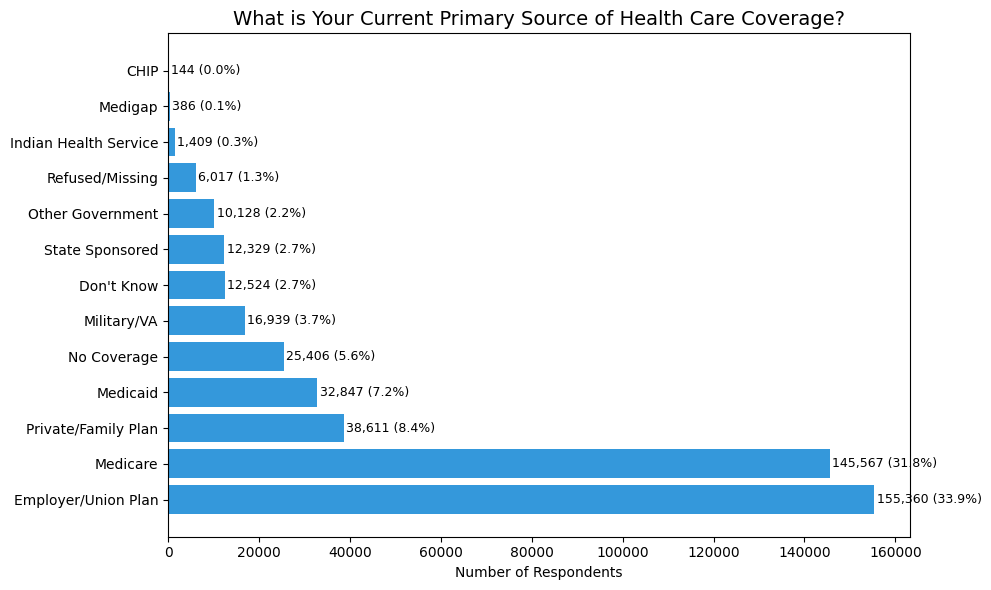

In [ ]:
#   Visuals for: What is Your Current Primary Source of Health Care Coverage?
insurance_type_labels = {
    1.0: "Employer/Union Plan",
    2.0: "Private/Family Plan",
    3.0: "Medicare",
    4.0: "Medigap",
    5.0: "Medicaid",
    6.0: "CHIP",
    7.0: "Military/VA",
    8.0: "Indian Health Service",
    9.0: "State Sponsored",
    10.0: "Other Government",
    88.0: "No Coverage",
    77.0: "Don't Know",
    99.0: "Refused/Missing"
}

insurance_type_data = df['insurance_type'].map(insurance_type_labels).value_counts()
percentages = df['insurance_type'].map(insurance_type_labels).value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(insurance_type_data.index, insurance_type_data.values, color='#3498db')

for bar, pct in zip(bars, percentages.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f} ({pct:.1f}%)',
            va='center', fontsize=9)

ax.set_title('What is Your Current Primary Source of Health Care Coverage?', fontsize=14)
ax.set_xlabel('Number of Respondents')
plt.tight_layout()
plt.show()



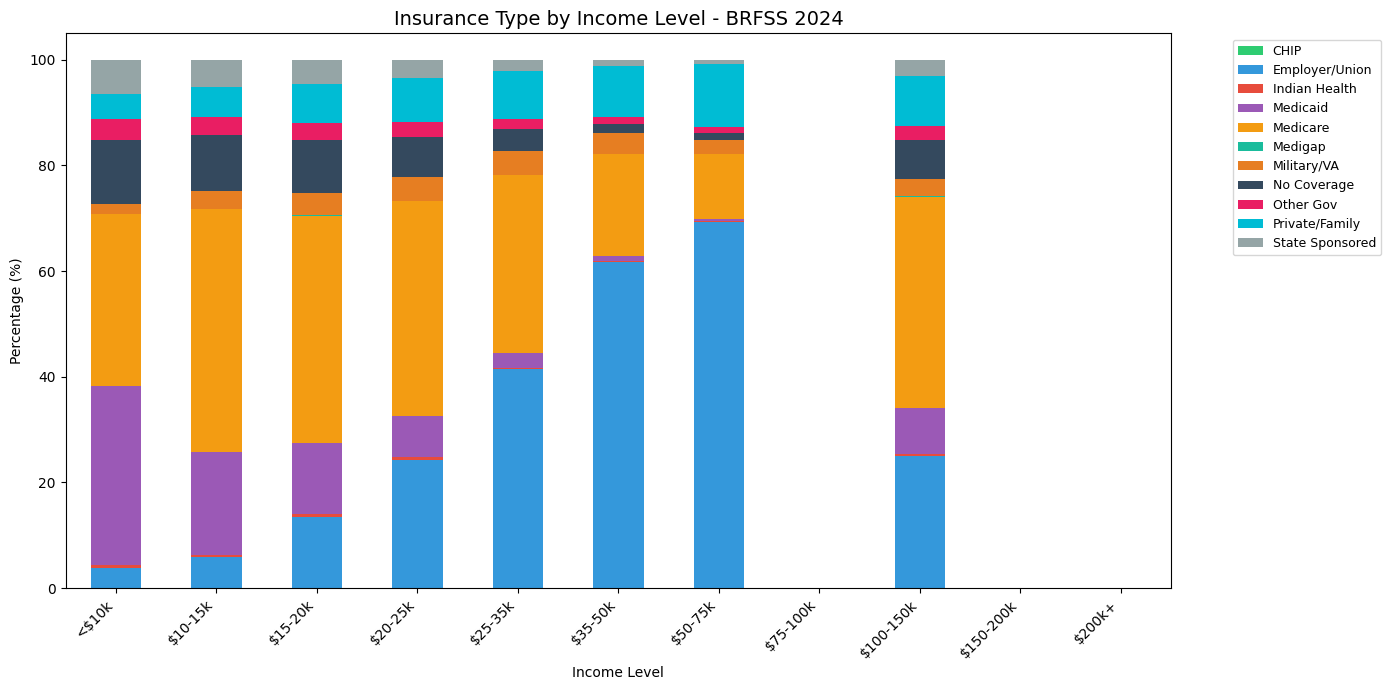

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Labels
income_labels = {
    1.0: "<$10k", 2.0: "$10-15k", 3.0: "$15-20k", 4.0: "$20-25k",
    5.0: "$25-35k", 6.0: "$35-50k", 7.0: "$50-75k", 8.0: "$75-100k",
    9.0: "$100-150k", 10.0: "$150-200k", 11.0: "$200k+"
}

insurance_labels = {
    1.0: "Employer/Union", 2.0: "Private/Family", 3.0: "Medicare",
    4.0: "Medigap", 5.0: "Medicaid", 6.0: "CHIP", 7.0: "Military/VA",
    8.0: "Indian Health", 9.0: "State Sponsored", 10.0: "Other Gov",
    88.0: "No Coverage"
}

# Filter out don't know/refused/missing
df_filtered = df[df['income_level'].isin(income_labels.keys()) & 
                 df['insurance_type'].isin(insurance_labels.keys())]

df_filtered = df_filtered.copy()
df_filtered['income_label'] = df_filtered['income_level'].map(income_labels)
df_filtered['insurance_label'] = df_filtered['insurance_type'].map(insurance_labels)

# Create crosstab as percentages
crosstab = pd.crosstab(
    df_filtered['income_label'],
    df_filtered['insurance_label'],
    normalize='index'
) * 100

# Reorder income levels
income_order = list(income_labels.values())
crosstab = crosstab.reindex(income_order)

# Plot
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12',
          '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4', '#95a5a6']

ax = crosstab.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)

ax.set_title('Insurance Type by Income Level - BRFSS 2024', fontsize=14)
ax.set_xlabel('Income Level')
ax.set_ylabel('Percentage (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

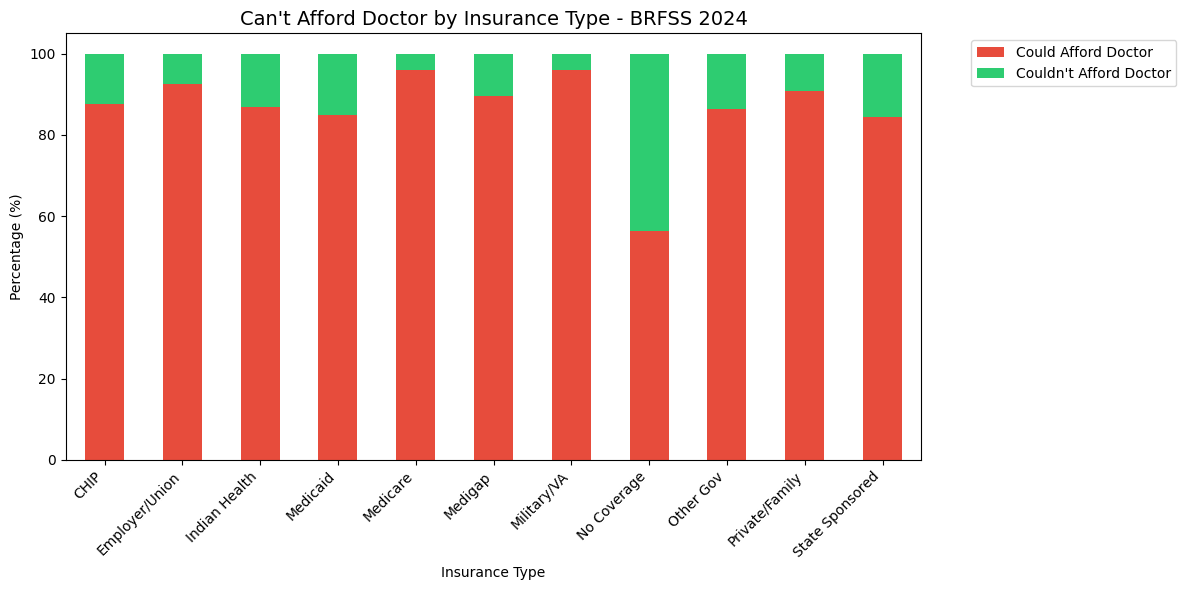

In [11]:
# Labels
cant_afford_labels = {
    1.0: "Couldn't Afford Doctor",
    2.0: "Could Afford Doctor"
}

insurance_labels = {
    1.0: "Employer/Union", 2.0: "Private/Family", 3.0: "Medicare",
    4.0: "Medigap", 5.0: "Medicaid", 6.0: "CHIP", 7.0: "Military/VA",
    8.0: "Indian Health", 9.0: "State Sponsored", 10.0: "Other Gov",
    88.0: "No Coverage"
}

# Filter
df_filtered = df[df['cant_afford_doctor'].isin(cant_afford_labels.keys()) &
                 df['insurance_type'].isin(insurance_labels.keys())].copy()

df_filtered['afford_label'] = df_filtered['cant_afford_doctor'].map(cant_afford_labels)
df_filtered['insurance_label'] = df_filtered['insurance_type'].map(insurance_labels)

# Crosstab
crosstab = pd.crosstab(
    df_filtered['insurance_label'],
    df_filtered['afford_label'],
    normalize='index'
) * 100

# Plot
colors = ['#e74c3c', '#2ecc71']
ax = crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)

ax.set_title("Can't Afford Doctor by Insurance Type - BRFSS 2024", fontsize=14)
ax.set_xlabel('Insurance Type')
ax.set_ylabel('Percentage (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

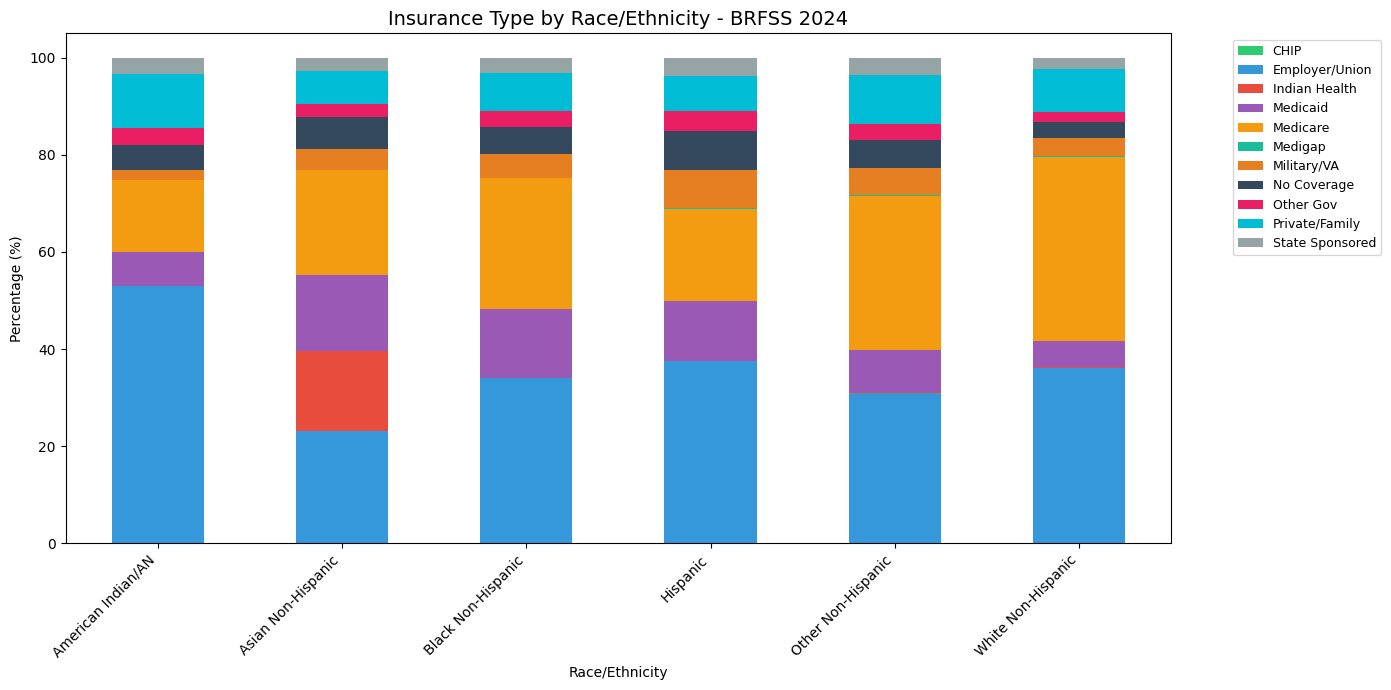

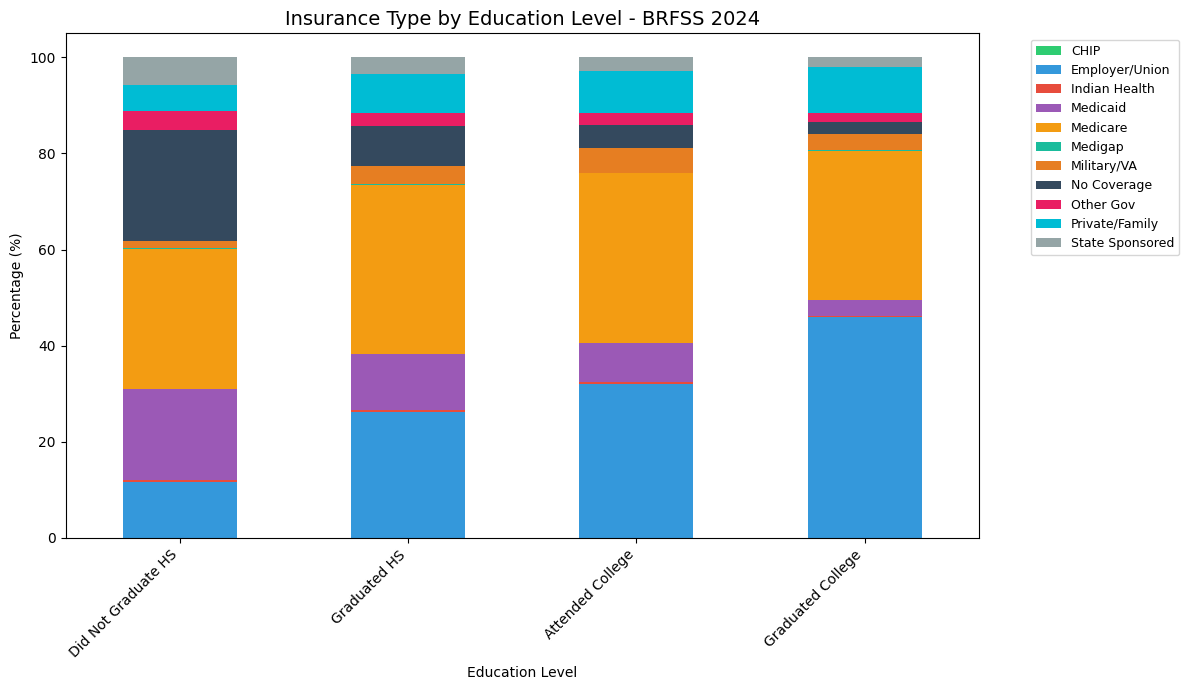

In [12]:
# ── RACE VS INSURANCE TYPE ───────────────────────────────────────────

race_labels = {
    1.0: "White Non-Hispanic",
    2.0: "Black Non-Hispanic",
    3.0: "Asian Non-Hispanic",
    4.0: "American Indian/AN",
    5.0: "Hispanic",
    6.0: "Other Non-Hispanic"
}

insurance_labels = {
    1.0: "Employer/Union", 2.0: "Private/Family", 3.0: "Medicare",
    4.0: "Medigap", 5.0: "Medicaid", 6.0: "CHIP", 7.0: "Military/VA",
    8.0: "Indian Health", 9.0: "State Sponsored", 10.0: "Other Gov",
    88.0: "No Coverage"
}

df_filtered = df[df['race_ethnicity'].isin(race_labels.keys()) &
                 df['insurance_type'].isin(insurance_labels.keys())].copy()

df_filtered['race_label'] = df_filtered['race_ethnicity'].map(race_labels)
df_filtered['insurance_label'] = df_filtered['insurance_type'].map(insurance_labels)

crosstab_race = pd.crosstab(
    df_filtered['race_label'],
    df_filtered['insurance_label'],
    normalize='index'
) * 100

colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12',
          '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4', '#95a5a6']

ax = crosstab_race.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)
ax.set_title('Insurance Type by Race/Ethnicity - BRFSS 2024', fontsize=14)
ax.set_xlabel('Race/Ethnicity')
ax.set_ylabel('Percentage (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# ── EDUCATION VS INSURANCE TYPE ──────────────────────────────────────

education_labels = {
    1.0: "Did Not Graduate HS",
    2.0: "Graduated HS",
    3.0: "Attended College",
    4.0: "Graduated College"
}

df_filtered2 = df[df['education_level'].isin(education_labels.keys()) &
                  df['insurance_type'].isin(insurance_labels.keys())].copy()

df_filtered2['education_label'] = df_filtered2['education_level'].map(education_labels)
df_filtered2['insurance_label'] = df_filtered2['insurance_type'].map(insurance_labels)

edu_order = list(education_labels.values())

crosstab_edu = pd.crosstab(
    df_filtered2['education_label'],
    df_filtered2['insurance_label'],
    normalize='index'
) * 100

crosstab_edu = crosstab_edu.reindex(edu_order)

ax2 = crosstab_edu.plot(kind='bar', stacked=True, figsize=(12, 7), color=colors)
ax2.set_title('Insurance Type by Education Level - BRFSS 2024', fontsize=14)
ax2.set_xlabel('Education Level')
ax2.set_ylabel('Percentage (%)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

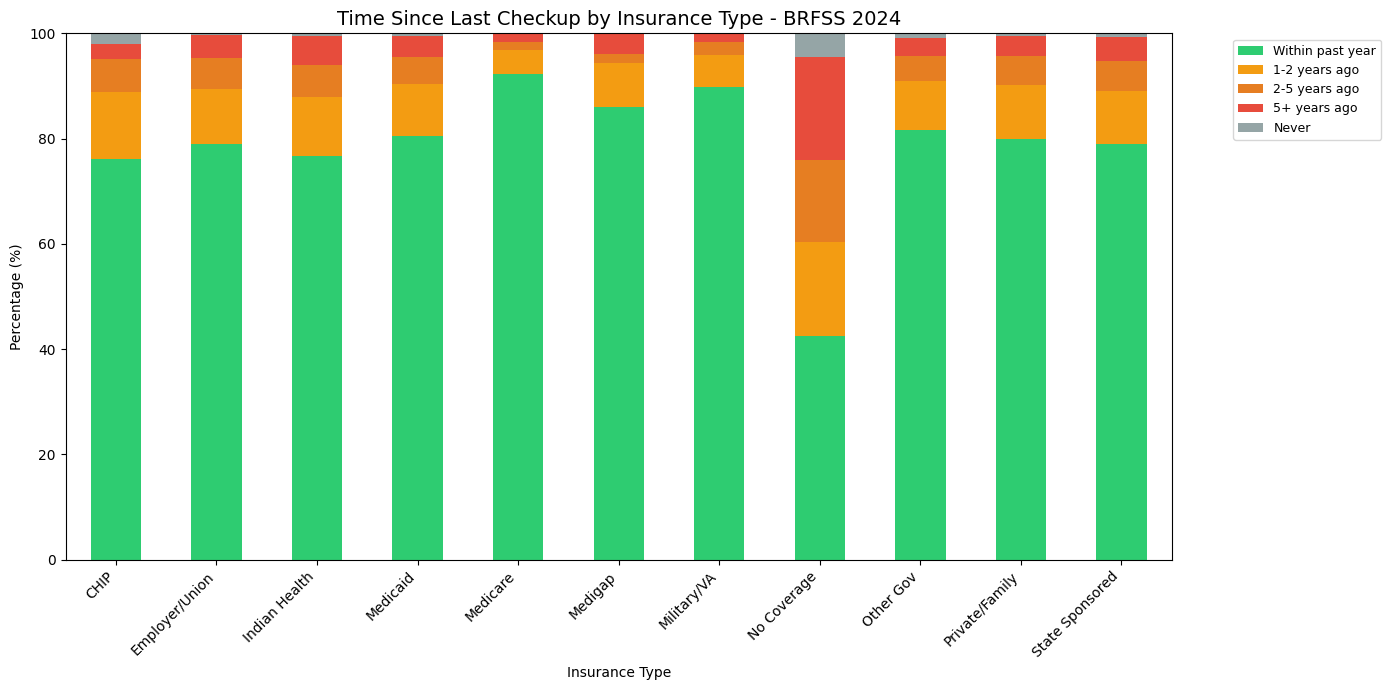

In [13]:
checkup_labels = {
    1.0: "Within past year",
    2.0: "1-2 years ago",
    3.0: "2-5 years ago",
    4.0: "5+ years ago",
    8.0: "Never"
}

insurance_labels = {
    1.0: "Employer/Union", 2.0: "Private/Family", 3.0: "Medicare",
    4.0: "Medigap", 5.0: "Medicaid", 6.0: "CHIP", 7.0: "Military/VA",
    8.0: "Indian Health", 9.0: "State Sponsored", 10.0: "Other Gov",
    88.0: "No Coverage"
}

df_filtered = df[df['time_since_checkup'].isin(checkup_labels.keys()) &
                 df['insurance_type'].isin(insurance_labels.keys())].copy()

df_filtered['checkup_label'] = df_filtered['time_since_checkup'].map(checkup_labels)
df_filtered['insurance_label'] = df_filtered['insurance_type'].map(insurance_labels)

checkup_order = list(checkup_labels.values())

crosstab = pd.crosstab(
    df_filtered['insurance_label'],
    df_filtered['checkup_label'],
    normalize='index'
) * 100

crosstab = crosstab.reindex(columns=checkup_order)

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#95a5a6']

ax = crosstab.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)
ax.set_title('Time Since Last Checkup by Insurance Type - BRFSS 2024', fontsize=14)
ax.set_xlabel('Insurance Type')
ax.set_ylabel('Percentage (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

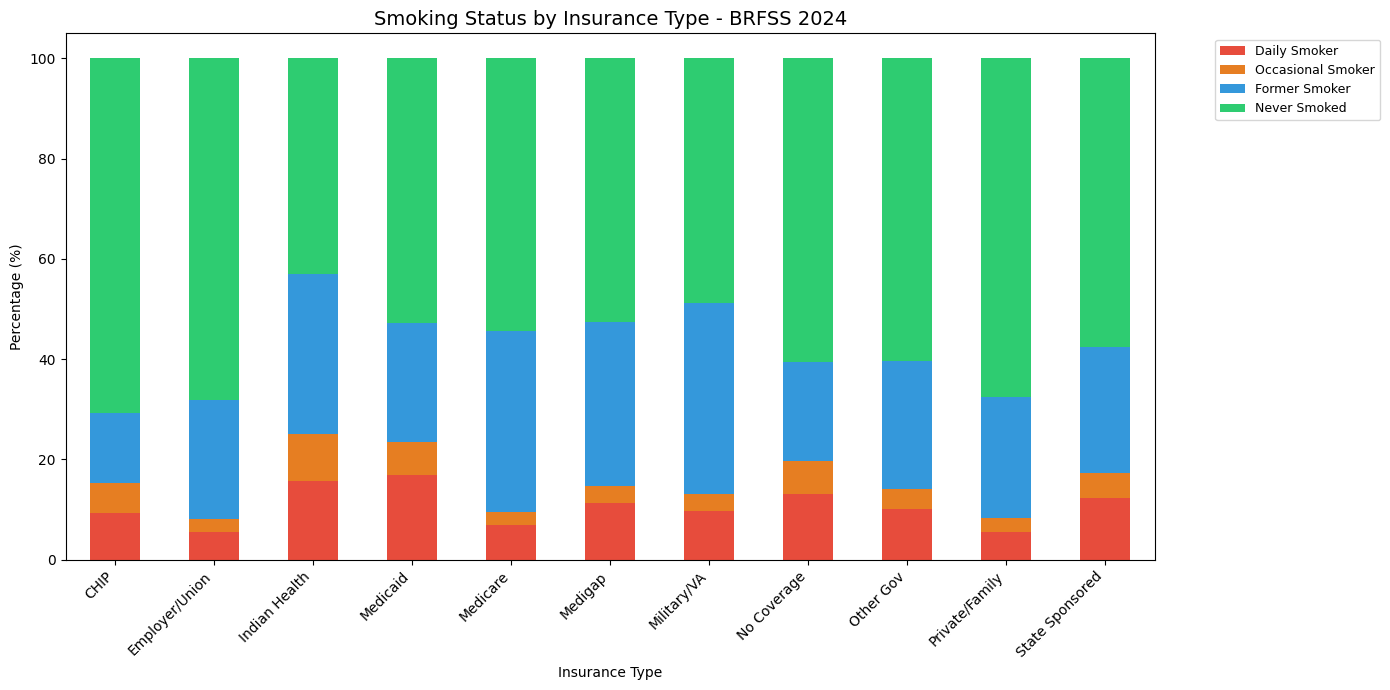

In [14]:
smoking_labels = {
    1.0: "Daily Smoker",
    2.0: "Occasional Smoker",
    3.0: "Former Smoker",
    4.0: "Never Smoked"
}

insurance_labels = {
    1.0: "Employer/Union", 2.0: "Private/Family", 3.0: "Medicare",
    4.0: "Medigap", 5.0: "Medicaid", 6.0: "CHIP", 7.0: "Military/VA",
    8.0: "Indian Health", 9.0: "State Sponsored", 10.0: "Other Gov",
    88.0: "No Coverage"
}

df_filtered = df[df['smoking_status'].isin(smoking_labels.keys()) &
                 df['insurance_type'].isin(insurance_labels.keys())].copy()

df_filtered['smoking_label'] = df_filtered['smoking_status'].map(smoking_labels)
df_filtered['insurance_label'] = df_filtered['insurance_type'].map(insurance_labels)

smoking_order = list(smoking_labels.values())

crosstab = pd.crosstab(
    df_filtered['insurance_label'],
    df_filtered['smoking_label'],
    normalize='index'
) * 100

crosstab = crosstab.reindex(columns=smoking_order)

colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

ax = crosstab.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)
ax.set_title('Smoking Status by Insurance Type - BRFSS 2024', fontsize=14)
ax.set_xlabel('Insurance Type')
ax.set_ylabel('Percentage (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/d4/djbcsnnd7dqfklgrhn2z_0fm0000gn/T/ipykernel_26824/3750884085.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mental = df_mental[df['days_poor_mental_health'].between(0, 30) |


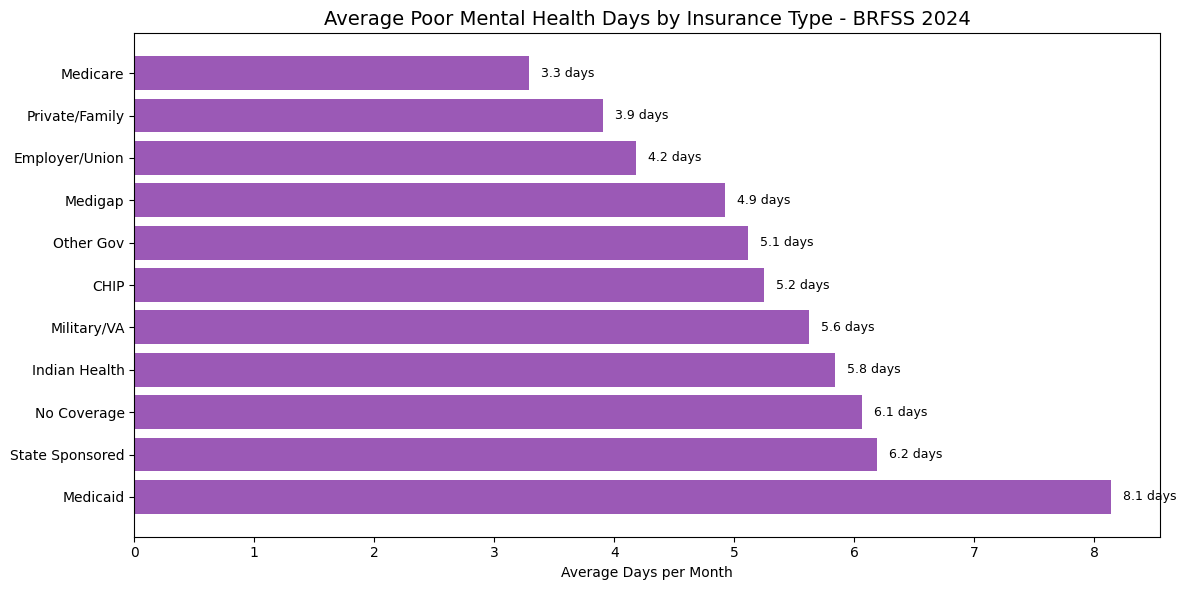

In [15]:
# Recode: 88 = 0 days (None), filter out 77/99
df_mental = df[df['insurance_type'].isin(insurance_labels.keys())].copy()
df_mental = df_mental[df['days_poor_mental_health'].between(0, 30) | 
                      (df['days_poor_mental_health'] == 88)]

df_mental['mental_health_days'] = df_mental['days_poor_mental_health'].replace(88.0, 0.0)
df_mental['insurance_label'] = df_mental['insurance_type'].map(insurance_labels)

# Average days per insurance type
avg_mental = df_mental.groupby('insurance_label')['mental_health_days'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(avg_mental.index, avg_mental.values, color='#9b59b6')

for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f} days',
            va='center', fontsize=9)

ax.set_title('Average Poor Mental Health Days by Insurance Type - BRFSS 2024', fontsize=14)
ax.set_xlabel('Average Days per Month')
plt.tight_layout()
plt.show()